# 💵Loan Applications

#### 1️⃣ Import statments

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import scipy.stats as stats

#### 2️⃣ Read Data

In [47]:
data = pd.read_csv("loan_applications.csv")
display(data.head())

,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Term,Default_Status
0,CUST100000,59,117603,76618,615,36,No
1,CUST100001,49,110649,125970,662,36,Yes
2,CUST100002,35,125470,40466,638,36,No
3,CUST100003,63,66024,27204,766,120,No
4,CUST100004,28,77391,17764,687,72,No


#### 4️⃣ Central Tendency & Dispersion

In [4]:
mean_income = data['Income'].mean()
median_income = data['Income'].median()
mode_income = data['Income'].mode()[0]

print(f"Mean Income: {mean_income}")
print(f"Median Income: {median_income}")
print(f"Mode Income: {mode_income}")

Mean Income: 69417.7654
Median Income: 69236.5
Mode Income: 15000


In [8]:
range_loan_amount = data['Loan_Amount'].max() - data['Loan_Amount'].min()
variance_loan_amount = data['Loan_Amount'].var()
standard_deviation_loan_amount = data['Loan_Amount'].std()

print(f"Range of Loan Amount: {range_loan_amount}")
print(f"Variance of Loan Amount: {variance_loan_amount}")
print(f"Standard Deviation of Loan Amount: {standard_deviation_loan_amount}")

Range of Loan Amount: 165807
Variance of Loan Amount: 770245609.8751127
Standard Deviation of Loan Amount: 27753.299080922123


#### 5️⃣ Probability & Events

In [10]:
default_count = (data["Default_Status"] == "Yes").sum()
total_customers = len(data)
prob_default = default_count / total_customers

print("Probability of Loan Default :", prob_default)
print("Probability (%) :", round(prob_default * 100, 2), "%")

Probability of Loan Default : 0.1852
Probability (%) : 18.52 %


In [21]:
contingency_table = pd.crosstab(data["Default_Status"], pd.cut(data["Credit_Score"], bins=3))
display(contingency_table)

Credit_Score,"(425.576, 567.333]","(567.333, 708.667]","(708.667, 850.0]"
Default_Status,,,
No,153,2416,1505
Yes,92,583,251


In [27]:
low_credit_default = (data["Default_Status"] == "Yes") & (data["Credit_Score"] < 600)
prob_low_credit_default = low_credit_default.sum() / (data["Credit_Score"] < 600).sum()
print("Probability of Default given Low Credit Score:", round(prob_low_credit_default * 100, 2), "%")

Probability of Default given Low Credit Score: 39.53 %


#### 6️⃣ Distribution & visualization

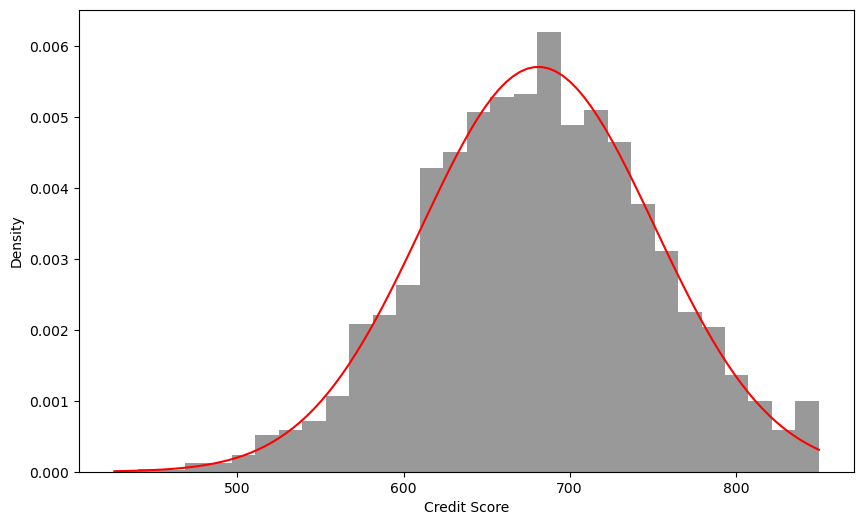

In [37]:
plt.figure(figsize=(10, 6))
plt.hist(data["Credit_Score"], bins=30, density=True, alpha=0.4, color='black')
plt.xlabel("Credit Score")
plt.ylabel("Density")
x = np.linspace(data["Credit_Score"].min(), data["Credit_Score"].max(), 100)
y = norm.pdf(x, data["Credit_Score"].mean(), data["Credit_Score"].std())
plt.plot(x, y, color='red')
plt.show()

In [39]:
skewness_loan_amount = data['Loan_Amount'].skew()
kurtosis_loan_amount = data['Loan_Amount'].kurt()
print(f"Skewness of Loan Amount: {skewness_loan_amount:.2f}")
print(f"Kurtosis of Loan Amount: {kurtosis_loan_amount:.2f}")

Skewness of Loan Amount: 0.79
Kurtosis of Loan Amount: 0.29


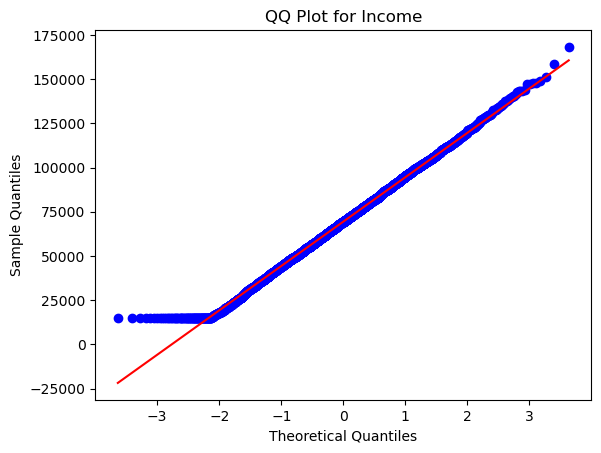

In [40]:
stats.probplot(data['Income'], dist="norm", plot=plt)
plt.title("QQ Plot for Income")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()


#### 7️⃣ Linear Algebra Applications

In [42]:
customer_vectors = data[['Income', 'Loan_Amount']].head(5)
display(customer_vectors)

,Income,Loan_Amount
0,117603,76618
1,110649,125970
2,125470,40466
3,66024,27204
4,77391,17764


In [46]:
dot_product = np.dot(customer_vectors.iloc[0], customer_vectors.iloc[1])
print(f"Dot Product between Customer 1 and Customer 2: {dot_product}")
norm_2 = np.linalg.norm(customer_vectors.iloc[0], ord=2)
print(f"Norm 2 of Customer 1's Financial Vector: {norm_2:.2f}")
angle_between_customers = np.arccos(dot_product / (np.linalg.norm(customer_vectors.iloc[0]) * np.linalg.norm(customer_vectors.iloc[1])))
print(f"Angle between Customer 1 and Customer 2's Financial Vectors (in degrees): {np.degrees(angle_between_customers):.2f}°")

Dot Product between Customer 1 and Customer 2: 22664223807
Norm 2 of Customer 1's Financial Vector: 140359.48
Angle between Customer 1 and Customer 2's Financial Vectors (in degrees): 15.62°
